1536
<class 'str'>
1/1 [==============================] - 0s 22ms/step


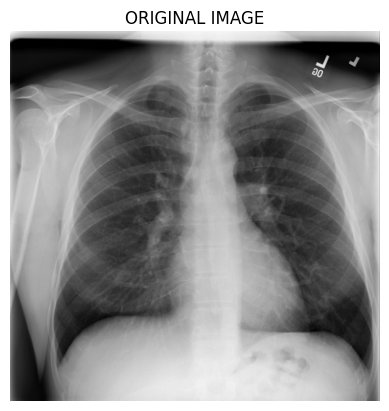

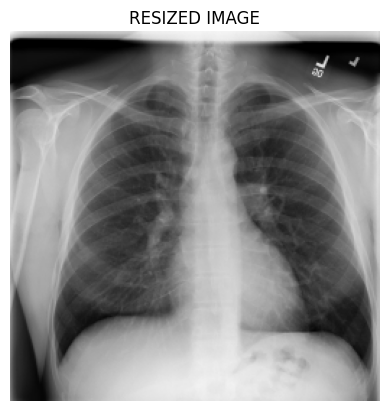

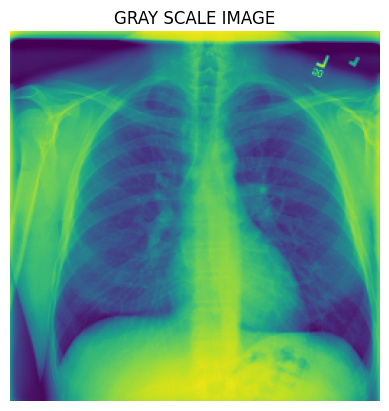

1/1 [==============================] - 0s 20ms/step


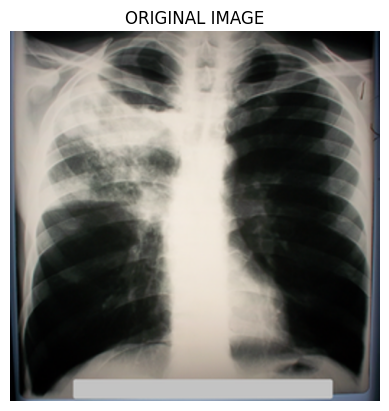

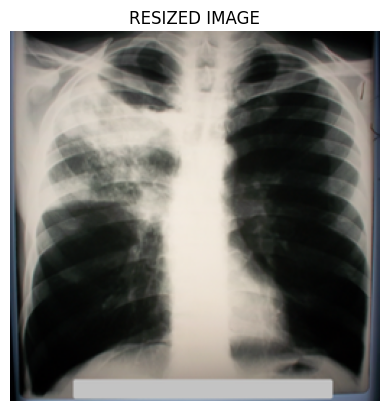

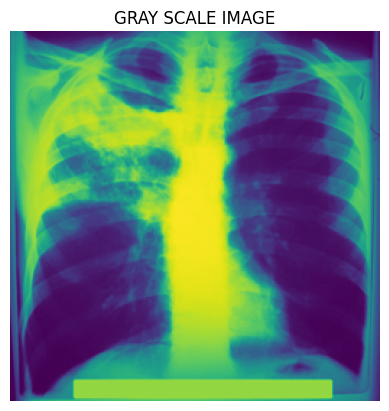

1/1 [==============================] - 0s 21ms/step
exit


In [5]:
from tkinter import *
import pyttsx3
import cv2
from tensorflow.keras.models import load_model
import nltk
import random
import numpy as np
import speech_recognition as sr
import matplotlib.pyplot as plt
import json
import pickle
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

with open('intents.json') as json_file:
    intents = json.load(json_file)

words=pickle.load(open('words.pkl','rb'))
classes=pickle.load(open('classes.pkl','rb'))
chat_model=load_model('chatbotmodel.h5')

tuberculosis_model=load_model('tuberculosis.h5')

def clean_up_sentence(sentence):  
    sentence_words=nltk.word_tokenize(sentence)
    sentence_words=[lemmatizer.lemmatize(word) for word in sentence_words]
    return sentence_words

def bag_of_words(sentence):    
    sentence_words=clean_up_sentence(sentence)
    bag=[0]*len(words)
    for w in sentence_words:
        for i,word in enumerate(words):
            if word == w:
                bag[i]=1
    return np.array(bag)

def predict_class(sentence):   
    bow=bag_of_words(sentence)
    res=chat_model.predict(np.array([bow]))[0]
    ERROR_THRESHOLD=0.25
    results=[[i,r] for i,r in enumerate(res) if r> ERROR_THRESHOLD]

    results.sort(key=lambda x:x[1],reverse=True)
    return_list=[]
    for r in results:
        return_list.append({'intent': classes[r[0]],'probability':str(r[1])})
    return return_list

def get_response(intents_list,intents_json):
    
    tag=intents_list[0]['intent']
    list_of_intents=intents_json['intents']
    for i in list_of_intents:
        if i['tag']==tag:
            result=random.choice(i['responses'])
            break
    return result

def chatexit():
    print("exit")
    window.destroy()

def clear_chat():
    text_box.config(state=NORMAL)
    text_box.delete(1.0, END)
    text_box.delete(1.0, END)
    text_box.config(state=DISABLED)

def test_ct_scan():
    file=filedialog.askopenfilename(filetypes=[("PNG files",'.png')])
    
    test_img=cv2.imread(file)
    mpimg = test_img
    test_img=cv2.resize(test_img,(256,256))
    test_input=test_img.reshape((1,256,256,3))
    
    img = mpimg
    plt.imshow(img)
    plt.title('ORIGINAL IMAGE')
    plt.axis ('off')
    plt.show()
   
    resized_image = cv2.resize(img,(256,256))
    img_resize_orig = cv2.resize(img,((256, 256)))
        
    fig = plt.figure()
    plt.title('RESIZED IMAGE')
    plt.imshow(resized_image)
    plt.axis ('off')
    plt.show()     
    #==== GRAYSCALE IMAGE ====      
    SPV = np.shape(img)
        
    try:            
        gray1 = cv2.cvtColor(img_resize_orig, cv2.COLOR_BGR2GRAY)
            
    except:
        gray1 = img_resize_orig
           
    fig = plt.figure()
    plt.title('GRAY SCALE IMAGE')
    plt.imshow(gray1)
    plt.axis ('off') 
    plt.show()
    
    result=tuberculosis_model.predict(test_input)
    if result[0]==0:
        test_result="0"
    else:
        test_result="1"
    res = chatbot_reply(test_result)       
    entry_field.delete(0, END) 
    engine=pyttsx3.init()
    speech=res
    engine.say(speech)
    engine.runAndWait()
    
def human_reply(user_input):
    text_box.image_create(END,image = Human_Image)
    pr1 = "" + user_input + "\n"
    text_box.configure(state=NORMAL)
    text_box.insert(END, pr1)
    text_box.configure(state=DISABLED)
    text_box.see(END)

def chatbot_reply(user_input):
    ints=predict_class(user_input)
    res=get_response(ints,intents)
    text_box.image_create(END,image = ChatBot_Image)
    pr = "" +res+ "\n"
    text_box.configure(state=NORMAL)
    text_box.insert(END, pr)
    text_box.configure(state=DISABLED)
    text_box.see(END)
    entry_field.delete(0, END)
    return res
      
def send_voice_message():
    r=sr.Recognizer()
    with sr.Microphone() as source:
        r.adjust_for_ambient_noise(source,duration=0)
        audio=r.listen(source)
    try:
        print(r.recognize_google(audio))
        entry_field.insert(0,r.recognize_google(audio))
    except sr.UnknownValueError:
        print("error")
    except sr.RequestError as e:
        print("error")
    user_input = entry_field.get()
    human_reply(user_input)
    chatbot_reply(user_input)       

def send_message():
    user_input = entry_field.get()
    human_reply(user_input)
    chatbot_reply(user_input)      

def msg():
    messagebox.showinfo("MedBot v1.0",
                        
                        'MedBot is a chatbot for answering TB related queries\nIt is based on retrival-based NLP using pythons NLTK tool-kit module\nGUI is based on Tkinter\nIt can answer questions regarding users health status')

def about():
    messagebox.showinfo("MedBot Developers",
                        "1.Moulya - 19CS062 \n2.Nandan C V - 19CS064\n3.Priya - 19CS075\n4.Raviteja T S - 19CS078",
                       )

window=Tk()
window.geometry("500x500")
window.title("Detection Of Tuberculosis")
window.config(bg="#FFFFFF")

menu = Menu(window)
window.config(menu=menu, bd=5)
# Menu bar

# File
file = Menu(menu, tearoff=0)
menu.add_cascade(label="File", menu=file, font= 'Helvetica 12')
# file.add_command(label="Save Chat Log", command=self.save_chat)
file.add_command(label="Clear Chat", command=clear_chat, font= 'Helvetica 12')
#  file.add_separator()
file.add_command(label="Exit", command=chatexit, font= 'Helvetica 12')

#help option
help_option = Menu(menu, tearoff=0)
menu.add_cascade(label="Help", menu=help_option)
help_option.add_command(label="About MedBot", command=msg, font= 'Helvetica 12')
help_option.add_command(label="Developers", command=about, font= 'Helvetica 12' )

#textbox
text_frame = Frame(window, bd=6)
text_frame.pack(expand=True, fill=BOTH)

 # scrollbar for text box
text_box_scrollbar = Scrollbar(text_frame, bd=0)
text_box_scrollbar.pack(fill=Y, side=RIGHT)

# contains messages
text_box = Text(text_frame, yscrollcommand=text_box_scrollbar.set, state=DISABLED,
                             bd=1, padx=6, pady=6, spacing3=8, wrap=WORD, font=("Aerial",14), relief=GROOVE,
                             width=10, height=1,bg="#FFFFFF", fg="#1f332e")
text_box.pack(expand=True, fill=BOTH)
text_box_scrollbar.config(command=text_box.yview,bg="#FFFFFF")


# frame containing user entry field
entry_frame = Frame(window, bd=1,bg="#FFFFFF")
entry_frame.pack(side=LEFT, fill=BOTH, expand=True)

# entry field
entry_field = Entry(entry_frame, bd=1, justify=LEFT,font=("Aerial",14),bg="#FFFFFF", fg="#1f332e", insertbackground="#1f332e")
entry_field.pack(fill=X, padx=6, pady=6, ipady=3)


send_button_frame = Frame(window, bd=0)
send_button_frame.pack(fill=BOTH)
        
voice_button_frame = Frame(window, bd=0)
voice_button_frame.pack(fill=BOTH)
        
file_button_frame = Frame(window, bd=0)
file_button_frame.pack(fill=BOTH)

photo=PhotoImage(file="send2.png")
photoimage=photo.subsample(14,18)

send_button = Button(send_button_frame,image=photoimage, width=40, relief=GROOVE, bg='#f2ebeb',
                                  bd=1,activebackground="#FFFFFF",command=send_message,
                                  activeforeground="#000000")
send_button.pack(side=LEFT, ipady=12, expand=True)

photo=PhotoImage(file="microphone.png")
photoimage1=photo.subsample(7,11)

voice_button = Button(send_button_frame,image=photoimage1,width=40, relief=GROOVE, bg='#f2ebeb',
                                  bd=1, activebackground="#FFFFFF",command=send_voice_message,
                                  activeforeground="#000000")
voice_button.pack(side=LEFT, ipady=12, expand=True)

photo=PhotoImage(file="file.png")
photoimage2=photo.subsample(18,18)
        
file_button = Button(send_button_frame,image=photoimage2, width=38, relief=GROOVE, bg='#f2ebeb',command=test_ct_scan,
                                  bd=1,activebackground="#FFFFFF",
                                  activeforeground="#000000")
file_button.pack(side=LEFT, ipady=12, expand=True)

#global Human_Image
Human_Image = PhotoImage(file="Human2.png")
Human_Image = Human_Image.subsample(4,4)

#global ChatBot_Image
ChatBot_Image = PhotoImage(file="ChatBot.png")
ChatBot_Image = ChatBot_Image.subsample(3,3)
      
print(window.winfo_screenwidth())
print(type(text_box.index(INSERT)))
window.mainloop()